# DRAFT — Anthropic's compute at the end of 2024

**The question:** how many H100-equivalents did Anthropic have at the end of
2024?

**The problem:** the one strong anchor — the leaked ~1.4 GW power figure — only
describes the end of **2025**. Nothing comparable exists for 2024; the only
hard data is Anthropic's reported cloud spend (\$2.5B in 2024, \$6.8B in 2025).

**The model in one line:** start from the end-2025 fleet we trust, and shrink
it twice — once because Anthropic was **spending less** at the end of 2024, and
once because **each dollar bought less** compute back then:

> end-2024 fleet = end-2025 fleet × (spending-rate ratio) × (dollar-strength ratio)

Section 2 builds the first ratio, section 3 the second, section 4 combines
them, section 5 re-derives the answer a second way to expose the key
assumption, and section 6 asks which input matters most.

*Provenance:* consolidates the backcast originally developed as §9 of
`anthropic_cloud_spend_monte_carlo` (which keeps the 2025 spend model this
reuses) and §5 of `lab_2024_backcasts` (which now imports this notebook's
result). **Draft status:** priors are notebook literals, not
`lab_model_params.csv` rows.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq

HERE = Path('.') if Path('frontier_lab_compute_model.py').exists() else Path('ai-lab-compute')
sys.path.insert(0, str(HERE.resolve()))
import frontier_lab_compute_model as frontier

N_SAMPLES = 5000
HOURS_PER_YEAR = 8760


def fmt(value):
    """Format an H100e count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'


def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]


def show(label, samples):
    lo, mid, hi = percentiles(samples)
    print(f'   {label:34s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 1. The starting point: the end-2025 fleet

The canonical power-based model (in the consolidated frontier script) turns the
leaked ~1.4 GW figure into chips via a Trainium2-vs-everything-else blend of
compute-per-watt. We take its samples as given — everything in this notebook
is about walking that number back one year.

One mechanical note: the frontier models reseed the shared random stream, so we
run them first, give the anchor samples a fixed shuffle, and draw this
notebook's own inputs from a different seed. That keeps the anchor and the
inputs statistically independent (fleet size and spend trajectory are separate
questions).

In [2]:
openai_res = frontier.model_openai()   # Anthropic borrows Nvidia specs from this
anthropic_2025 = frontier.model_anthropic(openai_res)
anthropic_2025 = anthropic_2025[np.random.default_rng(123).permutation(N_SAMPLES)]

sq.set_seed(2024)  # this notebook's own draws, independent of the frontier streams

print('End-2025 anchor (canonical power model):')
show('Anthropic end-2025 H100e', anthropic_2025)

End-2025 anchor (canonical power model):
   Anthropic end-2025 H100e          : 936k / 1.21M / 1.57M


## 2. Fewer dollars: the spending trajectory

Anthropic reportedly spent **\$2.5B on cloud compute in 2024** and **\$6.8B in
2025** (The Information; sampled as correlated lognormals, since both come from
the same reporting). Those are full-year *totals* — what the backcast needs is
the *rate* of spending right at each year-end.

If the spending rate grew smoothly (exponentially) through 2025, the two totals
pin down the average growth — about 2.7× per year — and the only remaining
question is *when* within the year the ramp happened. A **growth-shape factor**
(90% CI 0.6–1.6) covers that: below 1 means front-loaded (spending arrived
early, so the year started at a high rate), above 1 means back-loaded. The
end-2024 rate is then simply where the 2025 curve starts — end-2025 divided by
one year of within-2025 growth. Conveniently, no 2023 data is needed.

The chart checks the fitted curve against **SemiAnalysis's quarterly Anthropic
build** (their training costs + inference COGS, annualized at quarter
midpoints). Their model is calibrated to the same annual totals, so this
checks the *shape* of the ramp, not the level. Their path runs slightly
steeper than the smooth baseline (equivalent to a shape of ~1.3) and dips at
the year boundary, where they assume a large per-token cost drop.

In [3]:
spend24_dist, spend25_dist = sq.correlate((sq.to(2.2, 2.85), sq.to(6.0, 7.7)), 0.5)
spend_2024_total = (spend24_dist @ N_SAMPLES) * 1e9
spend_2025_total = (spend25_dist @ N_SAMPLES) * 1e9
avg_growth = np.log(spend_2025_total / spend_2024_total)
growth_shape = sq.to(0.6, 1.6) @ N_SAMPLES
inst_rate = avg_growth * growth_shape

# Year-end annualized run-rates of the exponential that integrates to the 2025
# total; the start-2025 rate is the end-2024 rate.
runrate_2025_end = spend_2025_total * inst_rate / (1 - np.exp(-inst_rate))
runrate_ratio = np.exp(-inst_rate)
runrate_2024_end = runrate_2025_end * runrate_ratio

print('Spending trajectory (5th / median / 95th):')
lo, mid, hi = percentiles(spend_2024_total)
print(f'   2024 full-year total ($B):        {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
lo, mid, hi = percentiles(spend_2025_total)
print(f'   2025 full-year total ($B):        {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
lo, mid, hi = percentiles(np.exp(avg_growth))
print(f'   2024->2025 avg growth factor:     {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(growth_shape)
print(f'   growth shape (1 = smooth ramp):   {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(runrate_2025_end)
print(f'   end-2025 spending rate ($B/yr):   {lo / 1e9:.1f} / {mid / 1e9:.1f} / {hi / 1e9:.1f}')
lo, mid, hi = percentiles(runrate_2024_end)
print(f'   end-2024 spending rate ($B/yr):   {lo / 1e9:.1f} / {mid / 1e9:.1f} / {hi / 1e9:.1f}')
lo, mid, hi = percentiles(runrate_ratio)
print(f'   => spending-rate ratio (24/25):   {lo:.2f} / {mid:.2f} / {hi:.2f}')

Spending trajectory (5th / median / 95th):
   2024 full-year total ($B):        2.19 / 2.50 / 2.85
   2025 full-year total ($B):        6.01 / 6.80 / 7.69
   2024->2025 avg growth factor:     2.40 / 2.71 / 3.08
   growth shape (1 = smooth ramp):   0.60 / 0.98 / 1.59
   end-2025 spending rate ($B/yr):   8.5 / 10.7 / 14.3
   end-2024 spending rate ($B/yr):   2.7 / 4.0 / 5.1
   => spending-rate ratio (24/25):   0.20 / 0.38 / 0.56


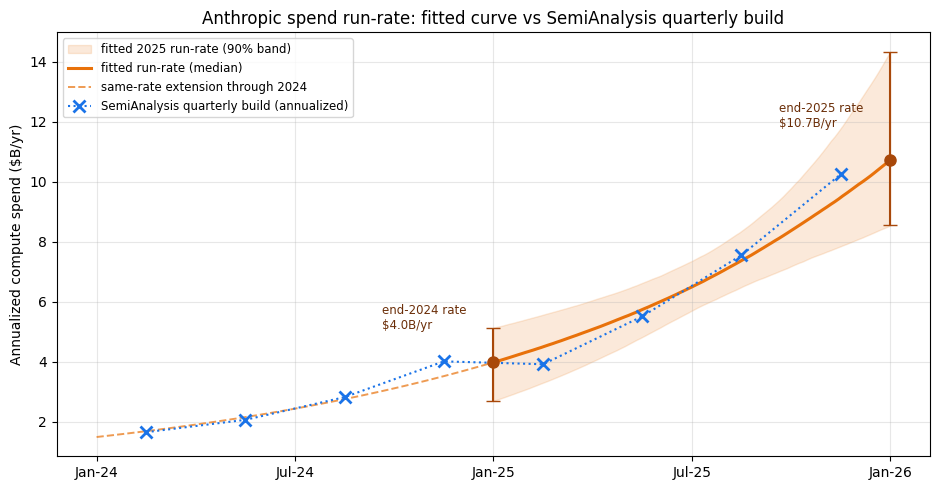

In [4]:
# SemiAnalysis's Anthropic financial model, quarterly training costs + inference
# COGS ($M). Calibrated to the same anchors (annual spend totals, ~1.4 GW
# end-2025), so it cross-checks the within-year shape rather than the level.
SA_QUARTERS = {
    2024.125: 300 + 114, 2024.375: 350 + 167, 2024.625: 400 + 306, 2024.875: 575 + 429,
    2025.125: 750 + 230, 2025.375: 950 + 429, 2025.625: 1150 + 739, 2025.875: 1400 + 1163,
}

fig, ax = plt.subplots(figsize=(9.5, 5))

# Fitted run-rate through 2025: per-sample paths -> a 90% band and the median.
u = np.linspace(0, 1, 101)
paths = runrate_2024_end[:, None] * np.exp(np.outer(inst_rate, u))
band_lo, band_med, band_hi = np.percentile(paths, [5, 50, 95], axis=0)
ax.fill_between(2025 + u, band_lo / 1e9, band_hi / 1e9, color='#e8710a', alpha=0.15,
                label='fitted 2025 run-rate (90% band)')
ax.plot(2025 + u, band_med / 1e9, color='#e8710a', lw=2.2, label='fitted run-rate (median)')

# Illustrative 2024 extension of the median path at the same growth rate.
r_med, r0_med = float(np.median(inst_rate)), float(np.median(runrate_2024_end))
t24 = np.linspace(0, 1, 50)
ax.plot(2024 + t24, r0_med * np.exp(r_med * (t24 - 1)) / 1e9, color='#e8710a', lw=1.4,
        ls='--', alpha=0.7, label='same-rate extension through 2024')

# The two year-end points the backcast actually uses.
for x, samples, label in [(2025.0, runrate_2024_end, 'end-2024 rate'),
                          (2026.0, runrate_2025_end, 'end-2025 rate')]:
    lo, mid, hi = percentiles(samples)
    ax.errorbar(x, mid / 1e9, yerr=[[(mid - lo) / 1e9], [(hi - mid) / 1e9]], fmt='o',
                color='#a8480a', markersize=8, capsize=5, zorder=5)
    ax.annotate(f'{label}\n${mid / 1e9:.1f}B/yr', xy=(x, mid / 1e9),
                xytext=(x - 0.28, mid / 1e9 + 1.1), fontsize=8.5, color='#6b2e08')

sa_x = list(SA_QUARTERS)
sa_y = [v * 4 / 1e3 for v in SA_QUARTERS.values()]
ax.plot(sa_x, sa_y, marker='x', ls=':', color='#1a73e8', markersize=8, mew=2,
        label='SemiAnalysis quarterly build (annualized)')

ax.set_xticks([2024, 2024.5, 2025, 2025.5, 2026])
ax.set_xticklabels(['Jan-24', 'Jul-24', 'Jan-25', 'Jul-25', 'Jan-26'])
ax.set_ylabel('Annualized compute spend ($B/yr)')
ax.set_title('Anthropic spend run-rate: fitted curve vs SemiAnalysis quarterly build', fontsize=12)
ax.legend(loc='upper left', fontsize=8.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Weaker dollars: what compute cost in each year

**In 2025**, Anthropic's dollars bought a cheap blend: Trainium2 priced near
Amazon's \$0.66/chip-hour cost (times a 1.0–1.6 markup), Blackwell, and Hopper
at 2025 contract rates — with the Nvidia side split so chip counts keep
OpenAI's Hopper:Blackwell ratio. At the central 55% Trainium share of spend,
the blend works out to roughly **\$1.36 per H100e-hour**. (Total spend cancels
out of this calculation, so it is purely a function of the price draws.)

**In 2024** there was no Trainium2 to buy — Project Rainier was only announced
in December 2024 — so the fleet was Hopper at 2024 long-term-contract rates
plus a TPU v5e slice that priced no better per H100e. That is sampled directly
as a prior: **\$2.0–3.0 per H100e-hour**.

The ratio of the two — a 2024 dollar bought only about **56%** as much compute
as a 2025 dollar — is the second shrink factor. Using a *ratio* has a nice
property: anything that affects both years the same way (partner discounts,
how utilization or billing is booked) cancels out; only the relative price
movement survives.

In [5]:
# Nvidia specs and the Hopper:Blackwell count ratio, borrowed from the OpenAI run.
h100e_per_gpu = openai_res['h100e_per_gpu']
counts = openai_res['counts']
hopper_per_blackwell = float(np.median(counts['H100/H200'])) / float(
    np.median(counts['B200'] + counts['B300']))
TRAINIUM2_H100E = 1299 / 1979
TRAINIUM_SPEND_SHARE = 0.55

hopper_dist, blackwell_dist = sq.correlate((sq.to(1.50, 2.00), sq.to(3.00, 4.00)), 0.8)
hopper_price = hopper_dist @ N_SAMPLES
blackwell_price = blackwell_dist @ N_SAMPLES
trainium_price = 0.66 * (sq.to(1.0, 1.6) @ N_SAMPLES)

# Effective 2025 price: what the 55%-Trainium spend blend pays per H100e-hour.
hopper_spend_share = (hopper_per_blackwell * hopper_price) / (
    hopper_per_blackwell * hopper_price + blackwell_price)
h100e_per_dollar_year = (
    (1 - TRAINIUM_SPEND_SHARE) * (
        hopper_spend_share * h100e_per_gpu['H100/H200'] / (hopper_price * HOURS_PER_YEAR)
        + (1 - hopper_spend_share) * h100e_per_gpu['B200'] / (blackwell_price * HOURS_PER_YEAR))
    + TRAINIUM_SPEND_SHARE * TRAINIUM2_H100E / (trainium_price * HOURS_PER_YEAR))
eff_price_2025 = 1 / (h100e_per_dollar_year * HOURS_PER_YEAR)

price_2024 = sq.to(2.0, 3.0) @ N_SAMPLES
cost_ratio = eff_price_2025 / price_2024

per_h100e_prices = {
    'Hopper 2025 rental': hopper_price / h100e_per_gpu['H100/H200'],
    'Blackwell 2025 rental': blackwell_price / h100e_per_gpu['B200'],
    'Trainium2 2025 (TCO x markup)': trainium_price / TRAINIUM2_H100E,
    'blended 2025 effective': eff_price_2025,
    '2024 prior': price_2024,
}
print('Prices, $ per H100e-hour (5th / median / 95th):')
print(f'   Hopper:Blackwell count ratio (OpenAI end-2025): {hopper_per_blackwell:.2f} : 1')
for name, arr in per_h100e_prices.items():
    lo, mid, hi = percentiles(arr)
    print(f'   {name:32s}: {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(cost_ratio)
print(f'   => dollar-strength ratio (2024$ buys vs 2025$): {lo:.2f} / {mid:.2f} / {hi:.2f}')

Prices, $ per H100e-hour (5th / median / 95th):
   Hopper:Blackwell count ratio (OpenAI end-2025): 1.23 : 1
   Hopper 2025 rental              : 1.51 / 1.73 / 2.00
   Blackwell 2025 rental           : 1.19 / 1.37 / 1.58
   Trainium2 2025 (TCO x markup)   : 1.01 / 1.27 / 1.60
   blended 2025 effective          : 1.17 / 1.36 / 1.57
   2024 prior                      : 2.01 / 2.45 / 3.02
   => dollar-strength ratio (2024$ buys vs 2025$): 0.43 / 0.55 / 0.71


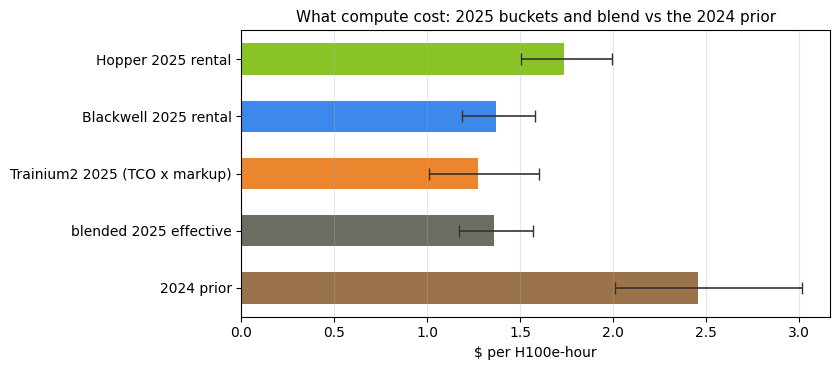

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ladder_colors = ['#76b900', '#1a73e8', '#e8710a', '#555349', '#8a5a2b']
for row, (name, arr) in enumerate(per_h100e_prices.items()):
    lo, mid, hi = percentiles(arr)
    ax.barh(len(per_h100e_prices) - 1 - row, mid, height=0.55, color=ladder_colors[row], alpha=0.85)
    ax.errorbar(mid, len(per_h100e_prices) - 1 - row, xerr=[[mid - lo], [hi - mid]],
                fmt='none', ecolor='#333333', elinewidth=1.2, capsize=4)
ax.set_yticks(range(len(per_h100e_prices)))
ax.set_yticklabels(list(reversed(list(per_h100e_prices))))
ax.set_xlabel('$ per H100e-hour')
ax.set_title('What compute cost: 2025 buckets and blend vs the 2024 prior', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 4. Putting it together

Multiply the three pieces: the end-2025 fleet, shrunk once for *fewer dollars*
(end-2024 spending ran at ~37% of the end-2025 rate) and once for *weaker
dollars* (each 2024 dollar bought ~56% as much compute).

The backcast, factor by factor (5th / median / 95th):
   end-2025 fleet (power model)      : 936k / 1.21M / 1.57M
   x fewer dollars (rate ratio)      : 228k / 451k / 733k
   x weaker dollars = END-2024 FLEET : 121k / 249k / 428k


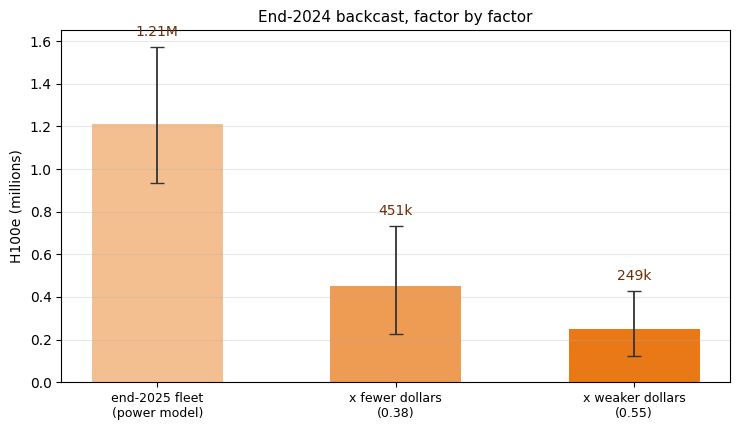

In [7]:
after_runrate = anthropic_2025 * runrate_ratio
anthropic_2024 = after_runrate * cost_ratio

print('The backcast, factor by factor (5th / median / 95th):')
show('end-2025 fleet (power model)', anthropic_2025)
show('x fewer dollars (rate ratio)', after_runrate)
show('x weaker dollars = END-2024 FLEET', anthropic_2024)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
stages = [('end-2025 fleet\n(power model)', anthropic_2025),
          (f'x fewer dollars\n({np.median(runrate_ratio):.2f})', after_runrate),
          (f'x weaker dollars\n({np.median(cost_ratio):.2f})', anthropic_2024)]
for col, (label, samples) in enumerate(stages):
    lo, mid, hi = percentiles(samples)
    ax.bar(col, mid / 1e6, width=0.55, color='#e8710a', alpha=0.45 + 0.25 * col)
    ax.errorbar(col, mid / 1e6, yerr=[[(mid - lo) / 1e6], [(hi - mid) / 1e6]],
                fmt='none', ecolor='#333333', elinewidth=1.3, capsize=5)
    ax.text(col, hi / 1e6 + 0.05, fmt(mid), ha='center', fontsize=10, color='#6b2e08')
ax.set_xticks(range(3))
ax.set_xticklabels([s[0] for s in stages], fontsize=9)
ax.set_ylabel('H100e (millions)')
ax.set_title('End-2024 backcast, factor by factor', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 5. The same number a second way — and the assumption it exposes

There is a more obvious way to estimate end-2024 that never touches the power
model: take the end-2024 spending rate (~\$4B/yr) and divide by what a chip
cost to rent (at \$2.45/hour, one H100e running around the clock costs about
\$21,500 a year). That **naive estimate** comes out around **185k chips**.

Why doesn't the backcast just say that? Because we can *test* the naive method
at end-2025, the one date with an independent answer. There it gives ~0.9M
chips — but the power model says ~1.2M. So dollars-divided-by-sticker-prices
**undercounts Anthropic's real fleet by about 1.34×**. We can't tell exactly
why (below-sticker pricing? the "every chip billed 24/7 at full rate"
assumption? a generous power figure?) — we just observe the gap.

The backcast's one big assumption is that **the same 1.34× undercount existed
in 2024**. Multiply the naive 185k by 1.34 and you get the backcast — exactly.
That is *not* a second piece of evidence; it is the same calculation
rearranged. The point of showing it is to make the hidden assumption visible:
the backcast is equivalent to claiming Anthropic *effectively* paid about
\$1.85/H100e-hour in 2024 rather than the \$2.45 sticker rate. If you instead
believe the discount only arrived with 2025 (the at-cost Trainium era), the
naive ~185k is your answer. That is the honest range of disagreement — and
SemiAnalysis's build, which prices 2024 at roughly sticker rates, sides with
the lower number.

In [8]:
naive_2024 = runrate_2024_end / (price_2024 * HOURS_PER_YEAR)
naive_2025 = runrate_2025_end / (eff_price_2025 * HOURS_PER_YEAR)
calibration = float(np.median(anthropic_2025)) / float(np.median(naive_2025))
implied_price_2024 = float(np.median(runrate_2024_end)) / (
    float(np.median(anthropic_2024)) * HOURS_PER_YEAR)

print('The second route (5th / median / 95th):')
show('naive spend-only end-2025', naive_2025)
show('naive spend-only end-2024', naive_2024)
print(f'   naive undercount at end-2025 (power/naive): {calibration:.2f}x')
print(f'   naive-2024 x {calibration:.2f} = {fmt(np.median(naive_2024) * calibration)}'
      f'  ~=  backcast median {fmt(np.median(anthropic_2024))}   (same number, rearranged)')
print(f'   implied effective 2024 price: ${implied_price_2024:.2f}/H100e-hr'
      f' (vs ${np.median(price_2024):.2f} sticker prior)')

# For scale: where this puts Anthropic relative to OpenAI's power model.
oai_by_date = openai_res['total_h100e_by_date']
oai24 = float(np.median(oai_by_date[[d for d in oai_by_date if d.year == 2024][0]]))
oai25 = float(np.median(openai_res['total_h100e']))
print(f'\nFor scale, vs OpenAI (medians): {np.median(anthropic_2024) / oai24:.2f}x at end-2024, '
      f'{np.median(anthropic_2025) / oai25:.2f}x at end-2025')
print(f'   implied Anthropic fleet growth during 2025: '
      f'{np.median(anthropic_2025) / np.median(anthropic_2024):.1f}x')

The second route (5th / median / 95th):
   naive spend-only end-2025         : 687k / 902k / 1.26M
   naive spend-only end-2024         : 120k / 184k / 255k
   naive undercount at end-2025 (power/naive): 1.34x
   naive-2024 x 1.34 = 247k  ~=  backcast median 249k   (same number, rearranged)
   implied effective 2024 price: $1.83/H100e-hr (vs $2.45 sticker prior)

For scale, vs OpenAI (medians): 0.64x at end-2024, 0.69x at end-2025
   implied Anthropic fleet growth during 2025: 4.9x


## 6. Which input matters most

The answer is three uncertain numbers multiplied together. To see which one
drives the spread, freeze two at their middle values and let one vary. The
**spending trajectory dominates** — specifically, whether 2025's \$6.8B arrived
early or late in the year. The sweep at the end turns exactly that knob;
SemiAnalysis's quarterly path corresponds to shape ≈ 1.3, in the lower-middle.

In [9]:
one_at_a_time = {
    'end-2025 power anchor': anthropic_2025 * np.median(runrate_ratio) * np.median(cost_ratio),
    'spending-rate ratio': np.median(anthropic_2025) * runrate_ratio * np.median(cost_ratio),
    'dollar-strength ratio': np.median(anthropic_2025) * np.median(runrate_ratio) * cost_ratio,
    'all combined': anthropic_2024,
}
print('End-2024 H100e, one factor varying at a time (5th / median / 95th):')
for name, arr in one_at_a_time.items():
    lo, mid, hi = percentiles(arr)
    print(f'   {name:22s}: {fmt(lo):>7} / {fmt(mid):>7} / {fmt(hi):>7}   (90% width {fmt(hi - lo)})')

print('\nGrowth-shape sweep (front-loaded 0.6 -> back-loaded 1.6) -> end-2024 median:')
for shape in [0.6, 0.8, 1.0, 1.2, 1.28, 1.4, 1.6]:
    ratio = np.exp(-avg_growth * shape)
    med = np.median(anthropic_2025 * ratio * cost_ratio)
    note = '   <- SemiAnalysis-implied shape' if shape == 1.28 else ''
    print(f'   shape {shape:4.2f}: rate ratio {np.median(ratio):.2f} -> {fmt(med)}{note}')

End-2024 H100e, one factor varying at a time (5th / median / 95th):
   end-2025 power anchor :    194k /    252k /    327k   (90% width 132k)


   spending-rate ratio   :    133k /    252k /    373k   (90% width 240k)
   dollar-strength ratio :    195k /    252k /    322k   (90% width 126k)
   all combined          :    121k /    249k /    428k   (90% width 307k)

Growth-shape sweep (front-loaded 0.6 -> back-loaded 1.6) -> end-2024 median:
   shape 0.60: rate ratio 0.55 -> 368k
   shape 0.80: rate ratio 0.45 -> 301k
   shape 1.00: rate ratio 0.37 -> 247k
   shape 1.20: rate ratio 0.30 -> 202k
   shape 1.28: rate ratio 0.28 -> 187k   <- SemiAnalysis-implied shape
   shape 1.40: rate ratio 0.25 -> 166k
   shape 1.60: rate ratio 0.20 -> 135k


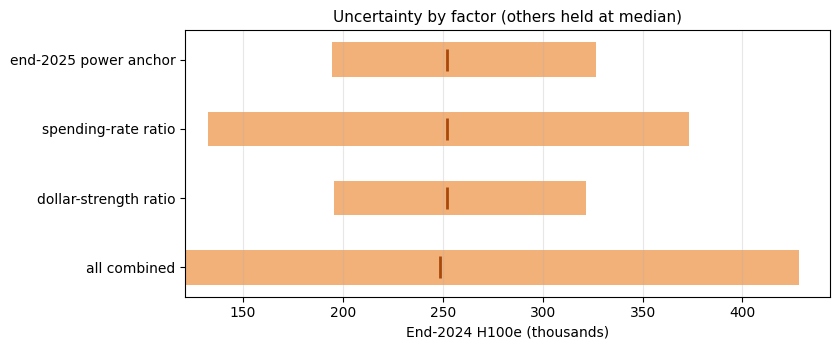

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for row, (name, arr) in enumerate(one_at_a_time.items()):
    lo, mid, hi = percentiles(arr)
    ax.barh(len(one_at_a_time) - 1 - row, (hi - lo) / 1e3, left=lo / 1e3,
            color='#e8710a', alpha=0.55, height=0.5)
    ax.plot(mid / 1e3, len(one_at_a_time) - 1 - row, marker='|', color='#a8480a',
            markersize=16, markeredgewidth=2)
ax.set_yticks(range(len(one_at_a_time)))
ax.set_yticklabels(list(reversed(list(one_at_a_time))))
ax.set_xlabel('End-2024 H100e (thousands)')
ax.set_title('Uncertainty by factor (others held at median)', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 7. Takeaways

- **Headline: ~250k H100e at end-2024** (90% CI roughly 125k–430k) — about a
  fifth of the end-2025 fleet, implying ~5× growth during 2025, holding steady
  at ~0.6–0.7× OpenAI at both year-ends.
- **The biggest lever is the spending trajectory** — how back-loaded 2025's
  \$6.8B was. Fixed shapes span ~370k (front-loaded) down to ~135k
  (back-loaded). A real quarterly spend figure would pin it; SemiAnalysis's
  quarterly build implies shape ≈ 1.3 → **~185–190k**.
- **The biggest structural doubt is the 1.34× correction** (section 5). Fully
  transportable to 2024 → ~250k; appeared only with 2025's at-cost era → the
  naive ~185k. A sampled "transport share" between those poles would make the
  doubt an explicit parameter — left as an open decision.
- **Promotion path:** priors into `lab_model_params.csv` (year-dimensioned), a
  per-year return in the frontier script's `model_anthropic`, and an extra
  (Anthropic × 2024) row in `lab_compute_tables`.